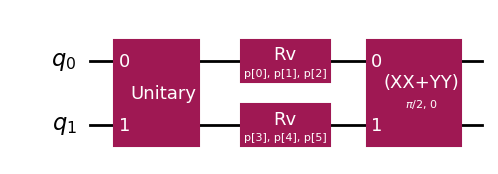

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RVGate, iSwapGate, CXGate
from qiskit.quantum_info import Operator
from qiskit.quantum_info.random import random_unitary
from scipy.optimize import minimize
from tqdm import tqdm

from gulps.core.invariants import GateInvariants
from gulps.viz.invariant_viz import scatter_plot

sentence_length = 2
random_restarts = 1
basis_gate = iSwapGate().power(1 / 2)


def ansatz():
    num_params = 6 * sentence_length
    p = ParameterVector("p", num_params)
    qc = QuantumCircuit(2)
    # qc.append(basis_gate.power(0.5), [0, 1])
    qc.append(GateInvariants.from_weyl((0.5, 0.5, 0.5)).gate, [0, 1])
    i = 0
    qc.append(RVGate(p[0 + 6 * i], p[1 + 6 * i], p[2 + 6 * i]), [0])
    qc.append(RVGate(p[3 + 6 * i], p[4 + 6 * i], p[5 + 6 * i]), [1])
    # qc.append(basis_gate.inverse(), [0, 1])
    qc.append(GateInvariants.from_weyl((0.5, 0.25, 0.25)).gate.inverse(), [0, 1])
    return qc, num_params


def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


successes = []

ansatz_qc, num_params = ansatz()
ansatz_qc.draw("mpl")

Naive synthesis: 100%|██████████| 1/1 [00:00<00:00,  6.44it/s]

Converged: 1/1


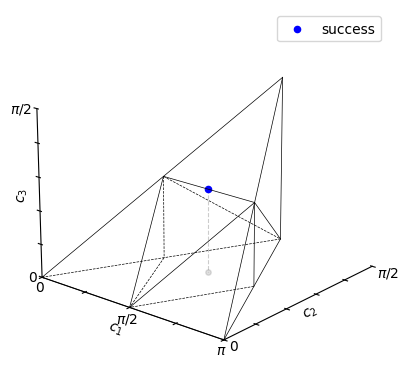

In [49]:
def bind_ansatz(p):
    bound_qc = ansatz_qc.assign_parameters(
        {param: val for param, val in zip(ansatz_qc.parameters, p)}
    )
    return GateInvariants.from_unitary(Operator(bound_qc))


successes = []
failures = []
# target_invariant = (GateInvariants.from_unitary(random_unitary(4)) for _ in range(N))
# target_invariant = [GateInvariants.from_weyl((0.5, 0.5, 0.5))]
target_invariant = [GateInvariants.from_weyl((0.5, 0.25, 0.25))]
N = 1
for target_gate in tqdm(
    target_invariant,
    total=N,
    desc="Naive synthesis",
):

    def makhlin_objective(p):
        U = bind_ansatz(p)
        return np.linalg.norm(np.array(U.makhlin) - np.array(target_gate.makhlin)) ** 2

    succeeded = False
    for _ in range(random_restarts):
        attempt = minimize(
            makhlin_objective,
            x0=np.pi * np.random.rand(num_params) - np.pi / 2,
            method="Nelder-Mead",
        )
        if attempt.success and attempt.fun < 1e-4:
            successes.append(target_gate)
            succeeded = True
            break
    if not succeeded:
        failures.append(target_gate)

print(f"Converged: {len(successes)}/{N}")
if successes:
    fig, ax = scatter_plot(successes, color="blue", label="success")
if failures:
    fig, ax = scatter_plot(failures, ax=ax, color="red", label="fail")
ax.legend()

In [50]:
attempt

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.3021677681964396e-34
             x: [ 1.427e+00  1.327e+00 -1.161e+00  2.173e-01  6.593e-01
                 -1.081e+00  7.799e-01 -1.991e-02  1.525e+00  1.400e+00
                  7.932e-01 -1.028e+00]
           nit: 64
          nfev: 209
 final_simplex: (array([[ 1.427e+00,  1.327e+00, ...,  7.932e-01,
                        -1.028e+00],
                       [ 1.427e+00,  1.327e+00, ...,  7.932e-01,
                        -1.028e+00],
                       ...,
                       [ 1.427e+00,  1.327e+00, ...,  7.932e-01,
                        -1.028e+00],
                       [ 1.427e+00,  1.327e+00, ...,  7.932e-01,
                        -1.028e+00]], shape=(13, 12)), array([ 3.302e-34,  9.953e-33, ...,  2.234e-31,  2.465e-31],
                      shape=(13,)))

In [40]:
attempt

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.564498129660961e-20
             x: [ 1.383e-01  1.566e+00 -1.383e-01  1.383e-01  1.566e+00
                 -1.383e-01  8.382e-01 -6.084e-02 -1.849e+00 -7.041e+00
                 -4.701e-01  3.285e+00]
           nit: 578
          nfev: 857
 final_simplex: (array([[ 1.383e-01,  1.566e+00, ..., -4.701e-01,
                         3.285e+00],
                       [ 1.383e-01,  1.566e+00, ..., -4.700e-01,
                         3.285e+00],
                       ...,
                       [ 1.383e-01,  1.566e+00, ..., -4.700e-01,
                         3.285e+00],
                       [ 1.383e-01,  1.566e+00, ..., -4.701e-01,
                         3.285e+00]], shape=(13, 12)), array([ 5.564e-20,  5.882e-20, ...,  6.075e-19,  9.639e-19],
                      shape=(13,)))

  0%|          | 0/2048 [00:00<?, ?it/s]

100%|██████████| 2048/2048 [00:01<00:00, 1910.95it/s]


(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>)

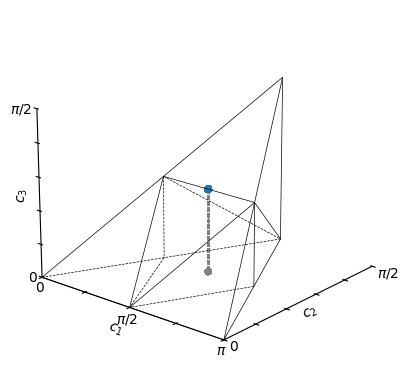

In [51]:
random_inv_list = []
for _ in tqdm(range(2048)):
    p = 2 * np.pi * np.random.rand(num_params) - np.pi / 2
    random_inv_list.append(bind_ansatz(p))
scatter_plot(random_inv_list)